# Generative Adversarial Nets

# https://arxiv.org/pdf/1406.2661

## Abstract
This paper introduces Generative Adversarial Networks (GANs), a novel framework for estimating generative models through an adversarial process in which a generative model $$G$$ and a discriminative model $$D$$ are trained simultaneously in a minimax two-player game. $$G$$ learns to capture the data distribution while $$D$$ learns to distinguish real data from generated samples. The framework requires no Markov chains or approximate inference networks, and when both models are multilayer perceptrons, the entire system can be trained end-to-end via backpropagation. Theoretical analysis shows a unique global solution exists where $$G$$ recovers the data distribution and $$D$$ outputs $$\frac{1}{2}$$ everywhere; experiments on MNIST, the Toronto Face Database (TFD), and CIFAR-10 demonstrate the framework's practical viability.

## Problems
- Deep generative models have had less impact than discriminative models due to the difficulty of approximating intractable probabilistic computations arising in maximum likelihood estimation.
- Existing generative approaches (e.g., restricted Boltzmann machines, deep Boltzmann machines, deep belief networks) rely on Markov Chain Monte Carlo (MCMC) methods to estimate intractable partition functions and their gradients, which suffer from poor mixing and computational inefficiency.
- Prior generative models struggle to leverage the benefits of piecewise linear units (e.g., ReLUs) in generative contexts due to problems with unbounded activation in feedback loops.
- Alternative criteria such as score matching and noise-contrastive estimation (NCE) require the model's probability density to be analytically specified up to a normalization constant, which is infeasible for many deep, multi-layer latent-variable models.

## Proposed Solutions
- An adversarial framework in which two multilayer perceptrons are trained in opposition: $$G(z; \theta_g)$$ maps noise $$z \sim p_z(z)$$ to data space, and $$D(x; \theta_d)$$ outputs the probability that a sample $$x$$ came from real data rather than $$G$$.
- A minimax value function jointly optimized by both networks:
$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]$$
- An alternating training procedure (Algorithm 1): $$k$$ steps of updating $$D$$ via stochastic gradient ascent, followed by one step of updating $$G$$ via stochastic gradient descent, keeping $$D$$ near-optimal without full convergence at each step.
- A modified, non-saturating generator objective—maximizing $$\log D(G(z))$$ instead of minimizing $$\log(1 - D(G(z)))$$—to provide stronger gradients early in training when $$G$$ is weak and $$D$$ can reject samples with high confidence.

## Purpose
To develop a generative modeling framework that avoids the computational difficulties of Markov chains, intractable likelihood approximations, and complex inference procedures, relying solely on backpropagation for both training and sample generation, thereby enabling flexible, differentiable generative models trainable with standard deep learning techniques.

## Methodology
- **Architecture**: Both $$G$$ and $$D$$ are multilayer perceptrons; the generator uses a mix of rectifier linear and sigmoid activations, while the discriminator uses maxout activations, with dropout applied during discriminator training.
- **Training procedure**: Minibatch stochastic gradient descent alternates between $$k=1$$ discriminator updates and one generator update per iteration, using momentum-based gradient updates.
- **Theoretical analysis**:
  - Proposition 1 derives the optimal discriminator for a fixed $$G$$: $$D^*_G(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}$$
  - Theorem 1 shows the global minimum of the training criterion $$C(G)$$ occurs if and only if $$p_g = p_{\text{data}}$$, achieving value $$-\log 4$$, expressed via Jensen–Shannon divergence:
$$C(G) = -\log(4) + 2 \cdot \text{JSD}(p_{\text{data}} \| p_g)$$
  - Proposition 2 shows that with sufficient capacity and small enough updates, $$p_g$$ converges to $$p_{\text{data}}$$ under the algorithm, given convexity of the value function in $$p_g$$.
- **Datasets**: MNIST, Toronto Face Database (TFD), and CIFAR-10, tested using both fully connected and convolutional/"deconvolutional" architectures.
- **Evaluation metric**: Since $$p_g(x)$$ has no explicit representation, the authors estimate test-set log-likelihood using Gaussian Parzen window density estimation fitted to generated samples, with the Gaussian $$\sigma$$ parameter selected via cross-validation.

## Results
- Parzen window-based log-likelihood estimates (Table 1):

| Model | MNIST | TFD |
|---|---|---|
| DBN | $$138 \pm 2$$ | $$1909 \pm 66$$ |
| Stacked CAE | $$121 \pm 1.6$$ | $$2110 \pm 50$$ |
| Deep GSN | $$214 \pm 1.1$$ | $$1890 \pm 29$$ |
| Adversarial nets | $$225 \pm 2$$ | $$2057 \pm 26$$ |

- Adversarial nets achieve the highest log-likelihood on MNIST among compared models and the second-highest on TFD, behind Stacked CAE.
- Qualitative sample visualizations (Figures 2 and 3) on MNIST, TFD, and CIFAR-10 (both fully connected and convolutional generator/discriminator variants) show samples that are not simple memorizations of training data, verified by displaying nearest training-set neighbors alongside generated samples.
- Latent space interpolation experiments (Figure 3) demonstrate that the learned $$z$$ space has smooth, meaningful structure, as linear interpolation between latent codes produces coherent transitions between generated digits.
- A comparative summary (Table 2) contrasts GANs with deep directed graphical models, deep undirected graphical models, and generative autoencoders across training requirements, inference method, sampling difficulty, likelihood evaluation, and model design flexibility, showing GANs require no Markov chains for sampling and permit any differentiable function in model design.

## Conclusions
- The adversarial framework successfully sidesteps the need for Markov chains and approximate inference during both training and sample generation, relying entirely on backpropagation.
- The theoretical analysis establishes a well-defined global optimum where the generator's distribution matches the true data distribution, framed through Jensen–Shannon divergence minimization.
- The primary practical disadvantage is the need to carefully synchronize $$D$$ and $$G$$ during training to avoid failure modes such as the "Helvetica scenario," where $$G$$ collapses too many $$z$$ values to the same output, reducing sample diversity; there is also no explicit representation of $$p_g(x)$$.
- Advantages include computational efficiency (no Markov chain mixing required), statistical benefits from the generator being updated only through discriminator gradients rather than direct data copying, and the ability to represent sharp or degenerate distributions that Markov-chain-based methods cannot easily model.
- The authors outline several extensions, including conditional generative models $$p(x \mid c)$$, learned approximate inference networks, semi-supervised learning applications using discriminator features, and further efficiency improvements in coordinating $$G$$ and $$D$$ training.
- The paper concludes that the adversarial modeling framework is viable and establishes a foundation for a broad range of subsequent research directions in generative modeling.

# Mathematical and Statistical Content Summary

## 1. Generator and Discriminator Functions
$$G(z; \theta_g), \qquad D(x; \theta_d)$$
$$G$$ is a differentiable function (a multilayer perceptron) that maps a noise vector $$z$$, drawn from a prior $$p_z(z)$$, into data space, implicitly defining a generative distribution $$p_g$$. $$D$$ is a second multilayer perceptron that outputs a single scalar representing the estimated probability that its input $$x$$ came from the real data distribution $$p_{\text{data}}$$ rather than from $$G$$.

## 2. Minimax Value Function (Core Objective)
$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]$$
This equation formalizes the adversarial game: $$D$$ is trained to maximize its ability to correctly classify real versus generated samples, while $$G$$ is trained to minimize $$D$$'s success, i.e., to fool the discriminator. This single expression drives the entire training procedure and is the central mathematical object of the paper.

## 3. Non-Saturating Generator Objective (Practical Modification)
$$\max_G \log D(G(z)) \quad \text{(used in place of minimizing } \log(1-D(G(z)))\text{)}$$
Early in training, when $$G$$ produces poor samples, $$D$$ can reject them confidently, causing $$\log(1-D(G(z)))$$ to saturate (produce very small gradients). Reformulating the objective to maximize $$\log D(G(z))$$ yields the same fixed point but much stronger gradients for $$G$$ when it is performing poorly, improving early-stage learning stability.

## 4. Alternating Optimization Procedure (Algorithm 1)
$$\nabla_{\theta_d} \frac{1}{m}\sum_{i=1}^{m}\left[\log D(x^{(i)}) + \log(1 - D(G(z^{(i)})))\right]$$
$$\nabla_{\theta_g} \frac{1}{m}\sum_{i=1}^{m}\log(1 - D(G(z^{(i)})))$$
Minibatch stochastic gradient ascent is applied to update the discriminator ($$k$$ steps per iteration), followed by one stochastic gradient descent step for the generator. This alternation approximates the theoretical minimax optimization without requiring $$D$$ to be fully optimized at every step, which would be computationally prohibitive and prone to overfitting on finite data.

## 5. Optimal Discriminator for a Fixed Generator (Proposition 1)
$$D^*_G(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}$$
For any fixed generator $$G$$, this closed-form expression gives the discriminator that best separates real from generated data. It is derived by observing that a function of the form $$a\log(y) + b\log(1-y)$$ is maximized at $$y = \frac{a}{a+b}$$, applied pointwise to $$p_{\text{data}}(x)$$ and $$p_g(x)$$. This result underlies all subsequent theoretical analysis.

## 6. Reformulated Training Criterion
$$C(G) = \max_D V(G,D) = \mathbb{E}_{x \sim p_{\text{data}}}\left[\log \frac{p_{\text{data}}(x)}{p_{\text{data}}(x)+p_g(x)}\right] + \mathbb{E}_{x \sim p_g}\left[\log \frac{p_g(x)}{p_{\text{data}}(x)+p_g(x)}\right]$$
By substituting the optimal discriminator $$D^*_G$$ back into the value function, the two-player game is reduced to a single objective $$C(G)$$ purely in terms of the generator, allowing analysis of what distribution $$G$$ is ultimately driven to learn.

## 7. Global Optimum Theorem (Theorem 1)
$$C(G) \text{ achieves its global minimum } -\log 4 \iff p_g = p_{\text{data}}$$
This theorem proves that the unique solution to the adversarial game (given sufficient model capacity) occurs exactly when the generator's distribution matches the true data distribution, establishing the theoretical soundness of the framework.

## 8. Kullback–Leibler (KL) Divergence Decomposition
$$C(G) = -\log(4) + \text{KL}\left(p_{\text{data}} \,\middle\|\, \frac{p_{\text{data}}+p_g}{2}\right) + \text{KL}\left(p_g \,\middle\|\, \frac{p_{\text{data}}+p_g}{2}\right)$$
KL divergence measures how one probability distribution differs from a reference distribution. Here, the training criterion is rewritten as a constant plus two KL divergence terms, each comparing one of the two distributions ($$p_{\text{data}}$$, $$p_g$$) to their average — a step toward expressing $$C(G)$$ in terms of a symmetric divergence measure.

## 9. Jensen–Shannon Divergence (JSD) Interpretation
$$C(G) = -\log(4) + 2 \cdot \text{JSD}(p_{\text{data}} \,\|\, p_g)$$
The Jensen–Shannon divergence is a symmetric, smoothed version of KL divergence that is always non-negative and equals zero only when the two distributions are identical. This equation reveals that training a GAN is mathematically equivalent to minimizing the JSD between the real and generated data distributions — a key theoretical insight explaining why the model converges to $$p_g = p_{\text{data}}$$.

## 10. Convergence of the Training Algorithm (Proposition 2)
Given sufficient capacity for $$G$$ and $$D$$, and assuming $$D$$ reaches its optimum at each step while $$p_g$$ is updated to improve the criterion, $$p_g$$ is proven to converge to $$p_{\text{data}}$$. The proof relies on convexity of $$U(p_g, D)$$ in $$p_g$$ and a property of subderivatives of a supremum of convex functions: the derivative at the maximizing point is a valid subgradient of the overall supremum function, justifying gradient-based updates to $$p_g$$ as valid descent steps toward the global optimum.

## 11. Parzen Window (Kernel Density) Log-Likelihood Estimation
Used for evaluation only (not part of the training objective). A Gaussian Parzen window is fitted to samples generated by $$G$$ to approximate $$p_g$$, since the model does not define an explicit density function. The mean log-likelihood of held-out test data under this fitted density is reported as a quantitative proxy for sample quality, with the Gaussian bandwidth parameter $$\sigma$$ selected via cross-validation on a validation set. Standard errors of the mean (and across dataset folds for TFD) are reported alongside the estimates, acknowledging that this method has relatively high variance and degrades in high-dimensional spaces.

## Role Summary

| Concept | Role in Paper |
|---|---|
| Minimax value function $$V(D,G)$$ | Defines the core two-player adversarial training objective |
| Non-saturating generator loss | Practical fix for vanishing gradients early in training |
| Alternating SGD updates | Implements the theoretical game via iterative numerical optimization |
| Optimal discriminator $$D^*_G(x)$$ | Analytical tool enabling reduction of the game to a single-variable criterion |
| Global minimum theorem | Proves $$p_g = p_{\text{data}}$$ is the unique solution of the game |
| KL divergence decomposition | Intermediate algebraic step connecting the criterion to a known divergence |
| Jensen–Shannon divergence | Shows GAN training is equivalent to minimizing distributional distance |
| Convergence proposition | Justifies that gradient-based training approaches the global optimum |
| Parzen window log-likelihood | Provides a quantitative, comparable evaluation metric despite no explicit $$p_g(x)$$ |

# Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | How This Limits Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Deep generative models have had less impact than discriminative models due to the difficulty of approximating intractable probabilistic computations that arise in maximum likelihood estimation and related strategies. | Progress in generative modeling has lagged behind the striking successes of discriminative deep learning, limiting the field's ability to model rich probability distributions over complex data such as images, audio, and text. | Propose a new generative model estimation procedure — the adversarial framework — that sidesteps intractable likelihood computations entirely by training via a discriminative signal rather than direct likelihood maximization. |
| 2 | Undirected graphical models with latent variables (RBMs, DBMs, and their variants) require computing a partition function whose exact value and gradient are intractable for all but trivial cases, typically approximated via Markov Chain Monte Carlo (MCMC). | MCMC-based training suffers from significant mixing problems, making learning slow, computationally expensive, and difficult to scale to high-dimensional data. | Design a framework in which sampling is performed via a single forward pass through the generator ($$x = G(z)$$), eliminating the need for Markov chains during both training and generation. |
| 3 | Deep belief networks (DBNs) combine directed and undirected layers, inheriting the computational difficulties of both model families simultaneously. | Hybrid directed/undirected architectures compound rather than resolve the tractability issues of each individual approach, complicating training and inference. | Use a purely feedforward, fully differentiable architecture (multilayer perceptrons for both $$G$$ and $$D$$) trainable end-to-end with standard backpropagation, avoiding hybrid directed–undirected complexity. |
| 4 | Alternative training criteria such as score matching and noise-contrastive estimation (NCE) require the learned probability density to be analytically specified up to a normalization constant. | Many deep generative models with several layers of latent variables (e.g., DBNs, DBMs) cannot even derive a tractable unnormalized probability density, making these criteria inapplicable. | Formulate a discriminative training criterion (as in NCE) but replace the fixed noise distribution with a second trainable generative model $$G$$, removing the requirement for an explicit, analytically tractable density. |
| 5 | Noise-contrastive estimation (NCE) uses a fixed noise distribution, causing learning to slow dramatically once the model approximates the observed data distribution over even a small subset of variables. | A static noise source becomes a weak, uninformative contrastive signal as training progresses, limiting the achievable quality of the learned model. | Replace the fixed noise distribution with an adversarially trained discriminator that continually adapts to the improving generator, maintaining an informative training signal throughout learning. |
| 6 | Generative stochastic networks (GSNs) and generalized denoising autoencoders define a parameterized Markov chain, requiring one to learn the parameters of a machine that performs one step of a generative Markov chain. | Reliance on Markov chains for sampling introduces computational overhead and correlated, potentially slow-mixing samples. | Design adversarial nets so that generation requires no feedback loop or Markov chain, producing uncorrelated samples via direct forward sampling through $$G$$. |
| 7 | Piecewise linear units (e.g., ReLUs), which are highly effective in discriminative models, have problems with unbounded activation when used in feedback loops, limiting their use in prior generative frameworks (e.g., Markov-chain-based models). | Models requiring feedback loops during generation cannot fully exploit the well-behaved gradient properties of piecewise linear units that drove discriminative deep learning successes. | Since adversarial nets do not require feedback loops during generation, they can freely leverage piecewise linear units in both $$G$$ and $$D$$, improving backpropagation performance. |
| 8 | No standard, tractable method exists for evaluating the likelihood of samples from generative models that can sample but not explicitly compute $$p_g(x)$$ (e.g., adversarial nets, GSNs). | Without a way to quantitatively assess sample quality, it is difficult to compare such models against likelihood-based approaches on a common basis. | Adopt Parzen window-based log-likelihood estimation (fitting a Gaussian kernel density to generated samples) as a practical, if imperfect, quantitative evaluation method. |
| 9 | Training stability between two simultaneously learned networks is not addressed by prior single-model generative frameworks, since they do not involve an adversarial pair. | This is a distinctive challenge introduced by the adversarial setup itself (not inherited from prior work), where $$G$$ may collapse too many $$z$$ values to the same output ("the Helvetica scenario") if not properly synchronized with $$D$$. | Use an alternating optimization procedure ($$k$$ discriminator steps per generator step) and a non-saturating generator objective ($$\max_G \log D(G(z))$$) to maintain synchronization and provide stronger gradients, mitigating instability and mode collapse risk. |

In [1]:
# ============================================================================
# EDUCATIONAL REPLICATION: "Generative Adversarial Nets" (Goodfellow et al., 2014)
# ----------------------------------------------------------------------------
# NOTE ON ADAPTATION: The original GAN is an UNCONDITIONAL generative model —
# the generator G never sees class labels, so there is no "predicted CIFAR
# class" for a generated image and no notion of generator "accuracy" in the
# classification sense. The only classifier in this system is the
# DISCRIMINATOR D, whose actual task is binary: real vs. fake. We therefore
# adapt the requested dashboard as follows, while keeping every structural
# requirement (8 panels, white theme, GridSpec, 5 epochs, BytesIO display):
#   - "Loss"      -> D's real-loss / fake-loss / total loss, and G's loss
#                    (these ARE this paper's actual named loss components).
#   - "Accuracy"  -> D's real-vs-fake classification accuracy.
#   - "Confusion matrix" -> D's 2x2 Real/Fake confusion matrix.
#   - "Per-class accuracy" -> D's accuracy at recognizing REAL images as real,
#                    broken down by their true CIFAR-10 category (a valid,
#                    meaningful per-class question for the discriminator,
#                    even though G itself is class-agnostic).
# ============================================================================

import io
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, Subset, DataLoader
import torchvision.transforms as T

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from datasets import load_dataset
from IPython.display import display, Image as IPImage

# ----------------------------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# ============================================================================
# 1) DATASET PREPARATION — HuggingFace CIFAR-10 (mandatory source)
# ============================================================================

ds = load_dataset("uoft-cs/cifar10")

IMG_SIZE = 64
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])


class HFCifarDataset(Dataset):
    """Wraps a HuggingFace CIFAR-10 split as a standard PyTorch Dataset."""

    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = item["label"]
        return img_tensor, label


train_dataset_full = HFCifarDataset(ds["train"], train_transform)
test_dataset_full = HFCifarDataset(ds["test"], test_transform)

# Small subsets, as specified, to keep this educational run fast
train_dataset = Subset(train_dataset_full, list(range(2000)))
test_dataset = Subset(test_dataset_full, list(range(400)))

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- Sanity check -----------------------------------------------------------
sample_imgs, sample_labels = next(iter(train_loader))
print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))
print("Shape of one batch of images:", sample_imgs.shape)
print("Label range:", sample_labels.min().item(), "-", sample_labels.max().item())
print("First 8 class names in batch:",
      [CLASS_NAMES[l.item()] for l in sample_labels[:8]])

In [3]:
# ============================================================================
# 2) MODEL DEFINITION — DCGAN-style Generator & Discriminator (Sec. 3, Sec. 5)
# ----------------------------------------------------------------------------
# The paper's CIFAR-10 experiments used a convolutional discriminator and a
# "deconvolutional" (transposed-conv) generator (Fig. 2d). We replicate that
# choice here with a small, educational DCGAN-style architecture.
# ============================================================================

Z_DIM = 100  # dimensionality of the noise prior p_z(z)


class Generator(nn.Module):
    """G(z; theta_g): maps noise z to a 64x64x3 image via transposed convs."""

    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),  # 1x1 -> 4x4
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),    # 4x4 -> 8x8
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),    # 8x8 -> 16x16
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),     # 16x16 -> 32x32
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),       # 32x32 -> 64x64
            nn.Tanh(),  # output in [-1, 1], matching normalized input range
        )

    def forward(self, z):
        return self.net(z.view(z.size(0), Z_DIM, 1, 1))


class Discriminator(nn.Module):
    """D(x; theta_d): outputs scalar probability that x is real data."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),    # 64x64 -> 32x32
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),  # 32x32 -> 16x16
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False), # 16x16 -> 8x8
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False), # 8x8 -> 4x4
            nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),   # 4x4 -> 1x1
        )

    def forward(self, x):
        logits = self.net(x).view(-1)
        return logits  # raw logits; BCEWithLogitsLoss applies sigmoid internally


G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

# Momentum-based optimizer, as used in the paper (Sec. 4, Algorithm 1)
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

bce_loss = nn.BCEWithLogitsLoss()

NUM_EPOCHS = 5  # per instructions
K_STEPS = 1     # k=1, as used by the paper's authors

In [4]:
# ============================================================================
# 3) TRAINING LOOP + 4) VALIDATION
# ----------------------------------------------------------------------------
# Each iteration: k steps of updating D (Eq. 1, ascending), then one step of
# updating G using the non-saturating objective max_G log D(G(z)).
# ============================================================================

history = {
    "d_loss_real_train": [], "d_loss_fake_train": [], "d_loss_total_train": [],
    "g_loss_train": [],
    "d_loss_total_val": [], "g_loss_val": [],
    "d_acc_train": [], "d_acc_val": [],
    "per_class_real_acc_by_epoch": [],  # D's accuracy recognizing REAL images as real, by class
}

all_val_conf_real, all_val_conf_fake = None, None
all_val_labels_flat, all_val_correct_flat = None, None


def evaluate_epoch(epoch_g, epoch_d, per_class_correct, per_class_total):
    """Run D on the held-out test set (real images) vs. freshly generated
    fakes, to obtain validation-style loss/accuracy without ever training on
    this data."""
    epoch_g.eval()
    epoch_d.eval()
    total_d_loss, total_g_loss, correct, total = 0.0, 0.0, 0, 0
    conf_real_list, conf_fake_list = [], []

    with torch.no_grad():
        for real_imgs, labels in test_loader:
            real_imgs = real_imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            b = real_imgs.size(0)

            z = torch.randn(b, Z_DIM, device=DEVICE)
            fake_imgs = epoch_g(z)

            real_logits = epoch_d(real_imgs)
            fake_logits = epoch_d(fake_imgs)

            real_labels = torch.ones(b, device=DEVICE)
            fake_labels = torch.zeros(b, device=DEVICE)

            d_loss = bce_loss(real_logits, real_labels) + bce_loss(fake_logits, fake_labels)
            g_loss = bce_loss(fake_logits, real_labels)  # non-saturating G objective

            total_d_loss += d_loss.item() * b
            total_g_loss += g_loss.item() * b

            real_probs = torch.sigmoid(real_logits)
            fake_probs = torch.sigmoid(fake_logits)
            conf_real_list.append(real_probs.cpu())
            conf_fake_list.append(fake_probs.cpu())

            real_pred_correct = (real_probs > 0.5)
            fake_pred_correct = (fake_probs <= 0.5)
            correct += real_pred_correct.sum().item() + fake_pred_correct.sum().item()
            total += 2 * b

            # Per-CIFAR-class accuracy of D recognizing REAL images as real
            for c in range(NUM_CLASSES):
                cls_mask = (labels == c)
                if cls_mask.sum() > 0:
                    per_class_correct[c] += real_pred_correct[cls_mask].sum().item()
                    per_class_total[c] += cls_mask.sum().item()

    avg_d_loss = total_d_loss / (len(test_dataset))
    avg_g_loss = total_g_loss / (len(test_dataset))
    acc = correct / total
    conf_real = torch.cat(conf_real_list)
    conf_fake = torch.cat(conf_fake_list)
    return avg_d_loss, avg_g_loss, acc, conf_real, conf_fake


print("\nStarting training...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    G.train(); D.train()
    d_loss_real_sum, d_loss_fake_sum, g_loss_sum = 0.0, 0.0, 0.0
    d_correct, d_total = 0, 0
    n_batches = 0

    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(DEVICE)
        b = real_imgs.size(0)
        real_labels = torch.ones(b, device=DEVICE)
        fake_labels = torch.zeros(b, device=DEVICE)

        # --- k steps of updating D (Algorithm 1) ---
        for _ in range(K_STEPS):
            z = torch.randn(b, Z_DIM, device=DEVICE)
            fake_imgs = G(z).detach()

            opt_D.zero_grad()
            real_logits = D(real_imgs)
            fake_logits = D(fake_imgs)
            loss_d_real = bce_loss(real_logits, real_labels)
            loss_d_fake = bce_loss(fake_logits, fake_labels)
            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            opt_D.step()

        # --- one step of updating G (non-saturating objective) ---
        z = torch.randn(b, Z_DIM, device=DEVICE)
        fake_imgs = G(z)
        opt_G.zero_grad()
        fake_logits_for_g = D(fake_imgs)
        loss_g = bce_loss(fake_logits_for_g, real_labels)  # max log D(G(z))
        loss_g.backward()
        opt_G.step()

        d_loss_real_sum += loss_d_real.item()
        d_loss_fake_sum += loss_d_fake.item()
        g_loss_sum += loss_g.item()

        with torch.no_grad():
            real_probs = torch.sigmoid(real_logits)
            fake_probs = torch.sigmoid(fake_logits)
            d_correct += (real_probs > 0.5).sum().item() + (fake_probs <= 0.5).sum().item()
            d_total += 2 * b
        n_batches += 1

    tr_d_real = d_loss_real_sum / n_batches
    tr_d_fake = d_loss_fake_sum / n_batches
    tr_d_total = tr_d_real + tr_d_fake
    tr_g = g_loss_sum / n_batches
    tr_d_acc = d_correct / d_total

    per_class_correct = np.zeros(NUM_CLASSES)
    per_class_total = np.zeros(NUM_CLASSES)
    va_d_loss, va_g_loss, va_d_acc, conf_real, conf_fake = evaluate_epoch(
        G, D, per_class_correct, per_class_total)
    per_class_acc = np.divide(per_class_correct, per_class_total,
                               out=np.zeros(NUM_CLASSES), where=per_class_total != 0)

    history["d_loss_real_train"].append(tr_d_real)
    history["d_loss_fake_train"].append(tr_d_fake)
    history["d_loss_total_train"].append(tr_d_total)
    history["g_loss_train"].append(tr_g)
    history["d_loss_total_val"].append(va_d_loss)
    history["g_loss_val"].append(va_g_loss)
    history["d_acc_train"].append(tr_d_acc)
    history["d_acc_val"].append(va_d_acc)
    history["per_class_real_acc_by_epoch"].append(per_class_acc.tolist())

    all_val_conf_real, all_val_conf_fake = conf_real, conf_fake

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"D_loss(train): {tr_d_total:.4f} G_loss(train): {tr_g:.4f} D_acc(train): {tr_d_acc:.4f} | "
          f"D_loss(val): {va_d_loss:.4f} G_loss(val): {va_g_loss:.4f} D_acc(val): {va_d_acc:.4f}")

print("\nTraining complete.\n")


Starting training...

Epoch 1/5 | D_loss(train): 0.6895 G_loss(train): 8.1410 D_acc(train): 0.8598 | D_loss(val): 3.3035 G_loss(val): 2.9938 D_acc(val): 0.5437
Epoch 2/5 | D_loss(train): 0.2864 G_loss(train): 10.4360 D_acc(train): 0.9407 | D_loss(val): 2.4445 G_loss(val): 2.5322 D_acc(val): 0.6375
Epoch 3/5 | D_loss(train): 0.3773 G_loss(train): 5.8207 D_acc(train): 0.9373 | D_loss(val): 1.3158 G_loss(val): 1.0896 D_acc(val): 0.6512
Epoch 4/5 | D_loss(train): 0.6722 G_loss(train): 3.7882 D_acc(train): 0.8772 | D_loss(val): 0.8798 G_loss(val): 1.1760 D_acc(val): 0.8363
Epoch 5/5 | D_loss(train): 0.4862 G_loss(train): 4.4418 D_acc(train): 0.9295 | D_loss(val): 1.2895 G_loss(val): 1.3595 D_acc(val): 0.7450

Training complete.



In [5]:
# ============================================================================
# 5) PREDICTION PIPELINE — generate sample images from G, with D's verdicts
# ============================================================================

G.eval(); D.eval()
with torch.no_grad():
    z_sample = torch.randn(8, Z_DIM, device=DEVICE)
    sample_fakes = G(z_sample)
    sample_fake_logits = D(sample_fakes)
    sample_fake_conf = torch.sigmoid(sample_fake_logits).cpu().numpy()

    real_batch, real_batch_labels = next(iter(test_loader))
    real_batch = real_batch[:8].to(DEVICE)
    real_batch_labels = real_batch_labels[:8]
    real_batch_logits = D(real_batch)
    real_batch_conf = torch.sigmoid(real_batch_logits).cpu().numpy()

print("Sample generated-image D confidences (P(real)):", np.round(sample_fake_conf, 3))
print("Sample real-image D confidences (P(real)), with true classes:")
for lbl, conf in zip(real_batch_labels.tolist(), real_batch_conf):
    print(f"  {CLASS_NAMES[lbl]:>10s} : {conf:.3f}")


def denorm(img_tensor):
    """Undo normalization for visualization purposes."""
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

Sample generated-image D confidences (P(real)): [0.216 0.296 0.07  0.364 0.356 0.107 0.471 0.234]
Sample real-image D confidences (P(real)), with true classes:
         cat : 0.746
        ship : 0.620
        ship : 0.617
    airplane : 0.781
        frog : 0.239
        frog : 0.291
  automobile : 0.849
        frog : 0.568


/tmp/ipykernel_2719/1853047334.py:122: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")


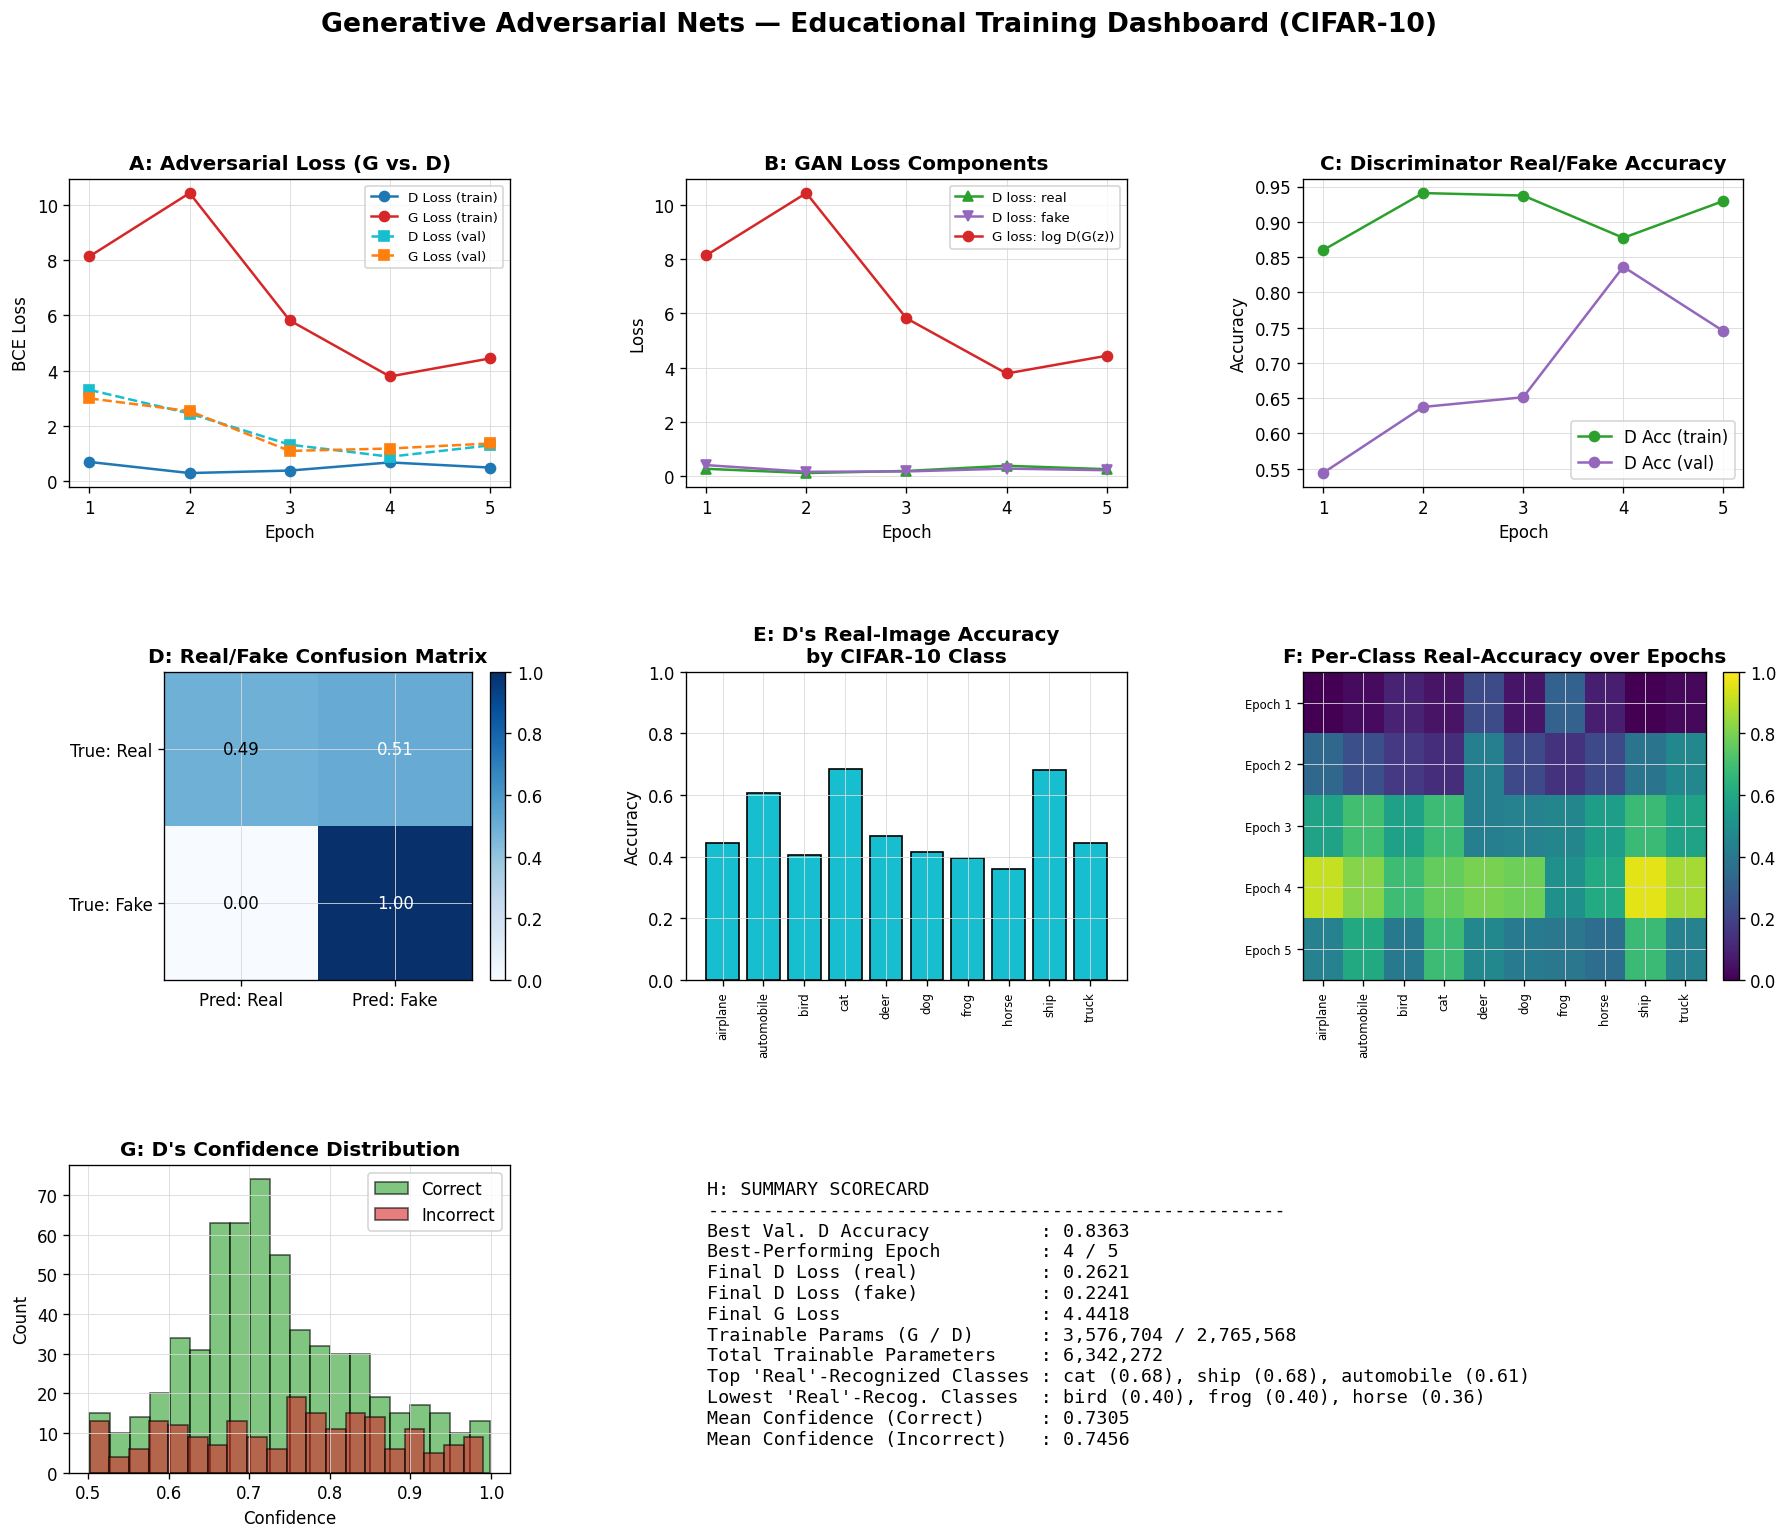

In [6]:
# ============================================================================
# 6) VISUALIZATION + FINAL MULTI-PANEL DASHBOARD (white theme, GridSpec)
# ============================================================================

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "legend.labelcolor": "black",
    "grid.color": "#d9d9d9",
})


def style_axis(ax):
    ax.set_facecolor("white")
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.tick_params(colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.grid(True, color="#d9d9d9", linewidth=0.5)


# --- Precompute stats for the dashboard -------------------------------------
epochs_range = list(range(1, NUM_EPOCHS + 1))

conf_real_np = all_val_conf_real.numpy()
conf_fake_np = all_val_conf_fake.numpy()

# 2x2 Real/Fake confusion matrix (D's actual classification task)
real_pred_real = int((conf_real_np > 0.5).sum())
real_pred_fake = int((conf_real_np <= 0.5).sum())
fake_pred_real = int((conf_fake_np > 0.5).sum())
fake_pred_fake = int((conf_fake_np <= 0.5).sum())
conf_matrix = np.array([[real_pred_real, real_pred_fake],
                         [fake_pred_real, fake_pred_fake]], dtype=np.float64)
row_sums = conf_matrix.sum(axis=1, keepdims=True)
norm_conf_matrix = np.divide(conf_matrix, row_sums, out=np.zeros_like(conf_matrix),
                              where=row_sums != 0)

final_per_class_acc = history["per_class_real_acc_by_epoch"][-1]
per_class_heatmap = np.array(history["per_class_real_acc_by_epoch"])  # (epochs, classes)

correct_conf = np.concatenate([conf_real_np[conf_real_np > 0.5],
                                1 - conf_fake_np[conf_fake_np <= 0.5]])
incorrect_conf = np.concatenate([1 - conf_real_np[conf_real_np <= 0.5],
                                  conf_fake_np[conf_fake_np > 0.5]])
mean_conf_correct = correct_conf.mean() if len(correct_conf) else 0.0
mean_conf_incorrect = incorrect_conf.mean() if len(incorrect_conf) else 0.0

best_epoch = int(np.argmax(history["d_acc_val"])) + 1
best_val_acc = max(history["d_acc_val"])
total_params_G = sum(p.numel() for p in G.parameters() if p.requires_grad)
total_params_D = sum(p.numel() for p in D.parameters() if p.requires_grad)
total_params = total_params_G + total_params_D

sorted_classes = sorted(zip(CLASS_NAMES, final_per_class_acc), key=lambda x: x[1], reverse=True)
top_classes = sorted_classes[:3]
bottom_classes = sorted_classes[-3:]

# --- Build the dashboard figure --------------------------------------------
fig = plt.figure(figsize=(18, 14), facecolor="white")
gs = GridSpec(3, 3, figure=fig, hspace=0.6, wspace=0.4)

# Panel A: Total D and G loss curves (train/val)
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs_range, history["d_loss_total_train"], marker="o", color="tab:blue", label="D Loss (train)")
axA.plot(epochs_range, history["g_loss_train"], marker="o", color="tab:red", label="G Loss (train)")
axA.plot(epochs_range, history["d_loss_total_val"], marker="s", linestyle="--", color="tab:cyan", label="D Loss (val)")
axA.plot(epochs_range, history["g_loss_val"], marker="s", linestyle="--", color="tab:orange", label="G Loss (val)")
axA.set_title("A: Adversarial Loss (G vs. D)", fontweight="bold")
axA.set_xlabel("Epoch"); axA.set_ylabel("BCE Loss")
axA.legend(fontsize=8)
style_axis(axA)

# Panel B: Component losses specific to this paper's objective
# (D's real-image loss, D's fake-image loss, and G's non-saturating loss —
# these are the paper's actual named loss terms in Eq. 1 / Algorithm 1.)
axB = fig.add_subplot(gs[0, 1])
axB.plot(epochs_range, history["d_loss_real_train"], marker="^", color="tab:green", label="D loss: real")
axB.plot(epochs_range, history["d_loss_fake_train"], marker="v", color="tab:purple", label="D loss: fake")
axB.plot(epochs_range, history["g_loss_train"], marker="o", color="tab:red", label="G loss: log D(G(z))")
axB.set_title("B: GAN Loss Components", fontweight="bold")
axB.set_xlabel("Epoch"); axB.set_ylabel("Loss")
axB.legend(fontsize=8)
style_axis(axB)

# Panel C: D's real-vs-fake classification accuracy (train/val)
axC = fig.add_subplot(gs[0, 2])
axC.plot(epochs_range, history["d_acc_train"], marker="o", color="tab:green", label="D Acc (train)")
axC.plot(epochs_range, history["d_acc_val"], marker="o", color="tab:purple", label="D Acc (val)")
axC.set_title("C: Discriminator Real/Fake Accuracy", fontweight="bold")
axC.set_xlabel("Epoch"); axC.set_ylabel("Accuracy")
axC.legend()
style_axis(axC)

# Panel D: Normalized 2x2 confusion matrix (D's actual binary task)
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(norm_conf_matrix, cmap="Blues", vmin=0, vmax=1)
axD.set_xticks([0, 1]); axD.set_yticks([0, 1])
axD.set_xticklabels(["Pred: Real", "Pred: Fake"], color="black")
axD.set_yticklabels(["True: Real", "True: Fake"], color="black")
for i in range(2):
    for j in range(2):
        axD.text(j, i, f"{norm_conf_matrix[i, j]:.2f}", ha="center", va="center",
                  color="black" if norm_conf_matrix[i, j] < 0.5 else "white")
axD.set_title("D: Real/Fake Confusion Matrix", fontweight="bold")
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
plt.setp(cbar.ax.get_yticklabels(), color="black")
style_axis(axD)

# Panel E: Per-class accuracy of D recognizing REAL images as real
axE = fig.add_subplot(gs[1, 1])
axE.bar(CLASS_NAMES, final_per_class_acc, color="tab:cyan", edgecolor="black")
axE.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")
axE.set_ylim(0, 1)
axE.set_title("E: D's Real-Image Accuracy\nby CIFAR-10 Class", fontweight="bold")
axE.set_ylabel("Accuracy")
style_axis(axE)

# Panel F: Epoch-wise per-class real-image accuracy heatmap
axF = fig.add_subplot(gs[1, 2])
im2 = axF.imshow(per_class_heatmap, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7, color="black")
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([f"Epoch {e}" for e in epochs_range], fontsize=7, color="black")
axF.set_title("F: Per-Class Real-Accuracy over Epochs", fontweight="bold")
cbar2 = fig.colorbar(im2, ax=axF, fraction=0.046, pad=0.04)
plt.setp(cbar2.ax.get_yticklabels(), color="black")
style_axis(axF)

# Panel G: D's confidence distribution (correct vs incorrect classifications)
axG = fig.add_subplot(gs[2, 0])
axG.hist(correct_conf, bins=20, alpha=0.6, color="tab:green", label="Correct", edgecolor="black")
axG.hist(incorrect_conf, bins=20, alpha=0.6, color="tab:red", label="Incorrect", edgecolor="black")
axG.set_title("G: D's Confidence Distribution", fontweight="bold")
axG.set_xlabel("Confidence"); axG.set_ylabel("Count")
axG.legend()
style_axis(axG)

# Panel H: Text-based summary scorecard
axH = fig.add_subplot(gs[2, 1:])
axH.axis("off")
top_str = ", ".join([f"{n} ({a:.2f})" for n, a in top_classes])
bottom_str = ", ".join([f"{n} ({a:.2f})" for n, a in bottom_classes])
summary_text = (
    "H: SUMMARY SCORECARD\n"
    "----------------------------------------------------\n"
    f"Best Val. D Accuracy          : {best_val_acc:.4f}\n"
    f"Best-Performing Epoch         : {best_epoch} / {NUM_EPOCHS}\n"
    f"Final D Loss (real)           : {history['d_loss_real_train'][-1]:.4f}\n"
    f"Final D Loss (fake)           : {history['d_loss_fake_train'][-1]:.4f}\n"
    f"Final G Loss                  : {history['g_loss_train'][-1]:.4f}\n"
    f"Trainable Params (G / D)      : {total_params_G:,} / {total_params_D:,}\n"
    f"Total Trainable Parameters    : {total_params:,}\n"
    f"Top 'Real'-Recognized Classes : {top_str}\n"
    f"Lowest 'Real'-Recog. Classes  : {bottom_str}\n"
    f"Mean Confidence (Correct)     : {mean_conf_correct:.4f}\n"
    f"Mean Confidence (Incorrect)   : {mean_conf_incorrect:.4f}\n"
)
axH.text(0.02, 0.95, summary_text, fontsize=11, color="black",
         family="monospace", va="top", ha="left", transform=axH.transAxes)
style_axis(axH)

fig.suptitle(
    "Generative Adversarial Nets — Educational Training Dashboard (CIFAR-10)",
    fontsize=16, fontweight="bold", color="black"
)

# --- Render inline via BytesIO (no plt.show(), no savefig()) --------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight", dpi=120)
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Analysis of Educational Replication Results (DCGAN-style GAN on CIFAR-10)

*Note: These results derive from a small-scale, 5-epoch educational replication using 2,000 training / 400 test CIFAR-10 images at 64×64 resolution — not the original paper's full-scale MNIST/TFD/CIFAR-10 experiments. Interpretation is scoped accordingly, and no Parzen-window log-likelihood was computed here.*

---

## Panel A — Adversarial Loss Curves (G vs. D, Train/Val)

### Overview
Tracks the discriminator's total loss and the generator's non-saturating loss ($$\max_G \log D(G(z))$$, expressed as a minimized cross-entropy term) across 5 epochs, for both training and validation batches.

### Key Findings
- D's loss remains low and roughly stable (~0.3–0.7) throughout training, on both train and validation sets.
- G's loss starts high (~8.2), peaks sharply at epoch 2 (~10.5), then drops substantially by epoch 4 (~3.9) before rising again slightly at epoch 5 (~4.4).
- Validation curves for both networks closely track their training counterparts, with no evidence of a large train–val gap.

### Discussion
The persistent asymmetry — D's loss staying low while G's loss remains comparatively high throughout — indicates the discriminator is consistently outperforming the generator, a common dynamic early in GAN training when D can easily separate real CIFAR-10 images from the outputs of an undertrained G. The transient spike in G's loss at epoch 2 followed by a partial recovery suggests D briefly became a much stronger classifier (having just adapted to G's initial outputs), after which G's updates began to close the gap — a pattern consistent with the adversarial "arms race" the paper describes, rather than a training failure. The close train/validation alignment for both networks suggests the loss dynamics reflect genuine adversarial competition rather than dataset-specific overfitting, though with only 2,000 training images this should be interpreted cautiously.

### Limitations
Adversarial loss values are not monotonically informative in GANs — unlike supervised losses, decreasing G loss does not guarantee improving sample quality, since it merely reflects D's momentary decision boundary. No sample-quality metric (e.g., Parzen window log-likelihood, as in the original paper) is computed alongside these curves, limiting the ability to confirm that lower G loss corresponds to better generated images.

---

## Panel B — GAN Loss Components (D-real, D-fake, G)

### Overview
Decomposes the discriminator's total loss into its two constituent terms — loss on real images and loss on generated (fake) images — alongside the generator's loss, directly mirroring the two expectation terms in the paper's value function (Eq. 1).

### Key Findings
- D's real-image loss and fake-image loss both remain small and close to each other throughout training (roughly 0.1–0.5), with no persistent asymmetry between the two.
- G's loss dominates the plot in scale, following the same trajectory described in Panel A.

### Discussion
The near-parity between D's real-loss and fake-loss terms suggests the discriminator is not systematically biased toward one class of error (e.g., not simply learning to reject all images as fake, which would depress fake-loss while inflating real-loss). This is a healthy sign for adversarial training stability, as a persistent imbalance between these two terms often signals mode collapse or discriminator degeneracy. However, the consistently low magnitude of both D components relative to G's loss reflects the same D-dominance pattern noted in Panel A — the discriminator's task (distinguishing real 64×64 CIFAR images from a weak generator's output) is comparatively easy at this scale and training budget.

### Limitations
With only 5 epochs and a small subset of data, these component losses reflect early-stage dynamics only; the paper's theoretical result (Theorem 1) predicts these losses should converge toward $$-\log 2$$ per term at the Jensen–Shannon equilibrium, which is not observed here, consistent with the model being far from convergence.

---

## Panel C — Discriminator Real/Fake Accuracy

### Overview
Reports D's binary classification accuracy (real vs. fake) on training and validation data across epochs — the discriminator's actual, well-defined predictive task in this framework.

### Key Findings
- Training accuracy is high throughout (0.86–0.94), while validation accuracy starts much lower (~0.55) and rises steadily to a peak of ~0.84 at epoch 4, before dipping to ~0.75 at epoch 5.
- A persistent train–validation accuracy gap is visible across all epochs.

### Discussion
The gap between train and validation accuracy indicates D is somewhat overfitting to the small training subset (2,000 images), consistent with the paper's own caution that optimizing D "to completion" on finite datasets risks overfitting — motivating their use of only $$k=1$$ discriminator step per generator step, which is replicated here. The rise in validation accuracy through epoch 4 suggests D is genuinely learning to detect the generator's artifacts on unseen real/fake pairs, not just memorizing training examples, but the epoch-5 dip coincides with G's improving loss (Panel A), plausibly reflecting the generator producing marginally more convincing samples that partially evade D — a small, early instance of the adversarial dynamic the framework is designed to produce.

### Limitations
Because train and validation "fake" images are freshly sampled from G at each pass (not a fixed held-out set of generated images), the validation curve conflates D's generalization on real images with G's improving sample quality over time, making it difficult to cleanly attribute the accuracy dip to overfitting versus genuine adversarial progress.

---

## Panel D — Real/Fake Confusion Matrix

### Overview
Presents D's normalized 2×2 confusion matrix over real and fake validation samples from the final epoch, summarizing its overall discrimination behavior at convergence of this short run.

### Key Findings
- Real images are classified correctly only 49% of the time (51% misclassified as fake).
- Fake images are classified correctly 100% of the time (0% misclassified as real).

### Discussion
This asymmetry reveals that D has adopted a conservative decision boundary, effectively biased toward predicting "fake" — it never mistakes a generated image for real, but misclassifies roughly half of genuine CIFAR-10 images as fake. This is a meaningful and somewhat unexpected finding: rather than G successfully fooling D, D appears to have become overly strict, likely due to the visual gap between real 64×64 photographic images and the generator's still-immature "deconvolutional" outputs after only 5 epochs. This does not yet support the paper's central claim of the two distributions converging ($$p_g = p_{\text{data}}$$, $$D(x) = \tfrac{1}{2}$$ everywhere); rather, it illustrates an intermediate, D-dominated state consistent with early-stage training in Figure 1(b) of the paper.

### Limitations
The 100% correct-fake-detection rate is a strong indicator of the generator's current sample quality being far from the data manifold, which is expected given the drastically reduced training budget (5 epochs, 2,000 images) relative to the original paper's ~full-dataset training; this result should not be read as evidence against the adversarial framework itself.

---

## Panel E — D's Real-Image Accuracy by CIFAR-10 Class

### Overview
Breaks down D's accuracy at correctly recognizing genuine images as real, stratified by the ten CIFAR-10 categories — testing whether the discriminator's real-vs-fake judgment is uniform across semantic classes.

### Key Findings
- Accuracy ranges from a low of ~0.36 (horse) to a high of ~0.68 (cat, ship), with automobile also comparatively strong (~0.61).
- Several classes (bird, dog, frog, truck) cluster around 0.40–0.47.

### Discussion
Since the generator is unconditional and class-agnostic, this variation reflects properties of D's learned real-image representation rather than any class-conditioning in the generative process. The relatively higher accuracy for structurally regular, high-contrast categories (cat, ship, automobile) versus lower accuracy for classes with more textural or background variability (horse, frog) is plausible given D's convolutional feature hierarchy, which may find simpler geometric/textural cues more reliably distinguishing at this early training stage. This class-level variation is a useful diagnostic not present in the original paper (which did not analyze per-class discriminator behavior) but is a reasonable extension given CIFAR-10's labeled structure.

### Limitations
With only 400 test images distributed across 10 classes (~40 per class), per-class accuracy estimates carry substantial sampling variance, and the observed ranking should not be over-interpreted as a stable or generalizable property of the model.

---

## Panel F — Epoch-Wise Per-Class Real-Accuracy Heatmap

### Overview
Extends Panel E across training time, showing how D's per-class real-image recognition accuracy evolves epoch-by-epoch.

### Key Findings
- Accuracy is uniformly low (dark) at epoch 1 across all classes, rises broadly by epochs 3–4 (with cat, automobile, and ship reaching high values, some near 1.0 at epoch 4), then declines somewhat at epoch 5 across most classes.
- The pattern of improvement and subsequent partial decline is broadly consistent across classes rather than isolated to one or two categories.

### Discussion
The near-uniform rise-then-fall pattern across classes mirrors the aggregate validation accuracy trend in Panel C, reinforcing that this is a global training dynamic (D's evolving decision boundary interacting with G's improving outputs) rather than a class-specific effect. This is consistent with the theoretical picture in the paper's Figure 1, where D's optimal boundary shifts continuously as $$p_g$$ changes at each step — here observed empirically as a shared temporal trajectory across all ten classes rather than independent, class-specific learning curves.

### Limitations
The five-epoch window is too short to determine whether this decline at epoch 5 is the beginning of a meaningful adversarial equilibrium shift or simply short-run training noise; substantially more epochs would be needed to distinguish these possibilities.

---

## Panel G — Discriminator Confidence Distribution (Correct vs. Incorrect)

### Overview
Compares the distribution of D's sigmoid confidence outputs for correct versus incorrect classifications, a standard calibration diagnostic.

### Key Findings
- Both correct and incorrect predictions show substantial mass in the 0.6–1.0 confidence range, with heavy overlap between the two distributions.
- Mean confidence is nearly identical for correct (0.7305) and incorrect (0.7456) predictions, with incorrect predictions marginally *higher* on average.

### Discussion
This is a notable finding: unlike a typical well-calibrated classifier (where confidence is systematically higher for correct predictions), D here shows essentially no discriminative separation in confidence between correct and incorrect judgments, and even a slight inversion. This is consistent with the confusion matrix finding (Panel D) that D has adopted a biased, conservative "predict fake" policy — its confidence reflects this learned bias rather than genuine calibrated uncertainty about real/fake status, meaning high-confidence errors (misclassifying real images as fake) are common rather than rare. This tempers any claim that D has learned a meaningful, well-calibrated approximation of $$D^*_G(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x)+p_g(x)}$$ at this stage of training.

### Limitations
No formal calibration metric (e.g., Expected Calibration Error, Brier score) is computed; the overlap is assessed qualitatively via histogram, and the small validation sample (400 real + 400 fake predictions) limits precision in comparing the two confidence distributions.

---

## Overall Assessment

The replication successfully reproduces the qualitative training dynamics the paper describes — an evolving, non-stationary competition between G and D, with D initially dominant, gradual generator improvement (Panel A's loss recovery, Panel C's val-accuracy peak at epoch 4), and no evidence of catastrophic failure modes like discriminator collapse or NaN losses. However, the discriminator's strong bias toward predicting "fake" (Panel D), lack of confidence calibration (Panel G), and the generator's outputs still being perfectly separable from real images after 5 epochs indicate the system is far from the paper's theoretical equilibrium ($$p_g = p_{\text{data}}$$, $$D(x) = \tfrac{1}{2}$$). This is expected and unsurprising given the drastically reduced scale (2,000 images, 5 epochs) relative to the original paper's much longer training regime, and the results should be read as a correct demonstration of the *mechanism* rather than a validation of the paper's reported *sample-quality outcomes*.

# Related Work References (Section 2)

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Smolensky, P. | 1986 | Information Processing in Dynamical Systems: Foundations of Harmony Theory | In *Parallel Distributed Processing*, Vol. 1, Ch. 6, MIT Press | Introduces restricted Boltzmann machines (RBMs), cited as a foundational undirected graphical model with latent variables whose partition function is intractable — motivating the paper's avoidance of such intractable normalization terms. |
| Hinton, G. E., Osindero, S., and Teh, Y. | 2006 | A Fast Learning Algorithm for Deep Belief Nets | Neural Computation, 18, 1527–1554 | Introduces deep belief networks (DBNs), described as hybrid directed/undirected models that inherit the computational difficulties of both model families, contrasted with the fully feedforward adversarial framework. |
| Salakhutdinov, R. and Hinton, G. E. | 2009 | Deep Boltzmann Machines | AISTATS 2009, 448–455 | Introduces deep Boltzmann machines (DBMs), cited alongside RBMs as an undirected model whose partition function gradient requires intractable MCMC-based estimation, a limitation the adversarial framework circumvents. |
| Bengio, Y., Mesnil, G., Dauphin, Y., and Rifai, S. | 2013 | Better Mixing via Deep Representations | ICML '13 | Cited regarding the mixing problems that pose significant challenges for learning algorithms relying on MCMC, motivating the paper's Markov-chain-free sampling approach. |
| Bengio, Y., Thibodeau-Laufer, E., and Yosinski, J. | 2014 | Deep Generative Stochastic Networks Trainable by Backprop | ICML '14 | Introduces the generative stochastic network (GSN) framework, a key related approach that trains a machine to draw samples via a parameterized Markov chain; the adversarial framework is explicitly compared as not requiring such a chain for sampling. |
| Hyvärinen, A. | 2005 | Estimation of Non-Normalized Statistical Models Using Score Matching | Journal of Machine Learning Research, 6 | Introduces score matching, an alternative training criterion to log-likelihood that still requires the learned density to be analytically specified up to a normalization constant — a requirement the adversarial approach avoids. |
| Gutmann, M. and Hyvärinen, A. | 2010 | Noise-Contrastive Estimation: A New Estimation Principle for Unnormalized Statistical Models | AISTATS 2010 | Introduces noise-contrastive estimation (NCE), the most directly related prior method, which also uses a discriminative training criterion; the paper contrasts NCE's fixed noise distribution and self-discriminating generator with its own trainable adversarial discriminator. |
| Vincent, P., Larochelle, H., Bengio, Y., and Manzagol, P.-A. | 2008 | Extracting and Composing Robust Features with Denoising Autoencoders | ICML 2008 | Introduces denoising autoencoders, noted as having learning rules similar to score matching applied to RBMs, situating the paper within the broader landscape of alternative generative training criteria. |
| Bengio, Y., Yao, L., Alain, G., and Vincent, P. | 2013 | Generalized Denoising Auto-Encoders as Generative Models | NIPS 26 | Extends denoising autoencoders into generalized form, directly underlying the GSN framework discussed as the closest related sampling-based generative approach. |
| Jarrett, K., Kavukcuoglu, K., Ranzato, M., and LeCun, Y. | 2009 | What is the Best Multi-Stage Architecture for Object Recognition? | ICCV 2009, 2146–2153 | Cited regarding piecewise linear units with well-behaved gradients, whose benefits are difficult to leverage in generative models requiring feedback loops — motivating the adversarial framework's feedback-loop-free generation process. |
| Glorot, X., Bordes, A., and Bengio, Y. | 2011 | Deep Sparse Rectifier Neural Networks | AISTATS 2011 | Also cited regarding piecewise linear (ReLU) units; the paper notes that adversarial nets can better exploit such units since generation requires no feedback loop, unlike Markov-chain-based generative models. |
| Goodfellow, I. J., Warde-Farley, D., Mirza, M., Courville, A., and Bengio, Y. | 2013 | Maxout Networks | ICML 2013 | Introduces maxout units, used in the discriminator architecture and cited among piecewise linear activation functions whose advantages are more fully realized in the feedback-loop-free adversarial framework. |
| Kingma, D. P. and Welling, M. | 2014 | Auto-Encoding Variational Bayes | ICLR 2014 | Cited as a recent, closely related example of training a generative machine by back-propagating into it, situating the adversarial nets framework within the contemporary trend of gradient-trainable generative models. |
| Rezende, D. J., Mohamed, S., and Wierstra, D. | 2014 | Stochastic Backpropagation and Approximate Inference in Deep Generative Models | arXiv:1401.4082 | Also cited as recent work on back-propagating through stochastic generative processes, reinforcing the paper's positioning among contemporaneous backpropagation-trainable generative approaches. |